# Low-temperature dePablo latent auxetic edit

Train an AE on `data/depablo-near-zero-temp.pt`, learn an initial-latent direction that lowers final p-ratio, choose a non-auxetic held-out network, decode edited latents with the original graph context, and render the decoded path as a GIF.

This notebook uses the AE decoder as the generator. It computes p-ratio on the decoded graph/path with the existing side-based p-ratio utility, and can also validate selected decoded designs with MetaForge/LAMMPS elastic simulation.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import pandas as pd

from scripts.latent_auxetic_edit_depablo import run_low_temp_auxetic_edit

PROJECT_ROOT

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/home/alexz/Documents/course_project')

In [2]:
# Main knobs. Start small if you want a quick smoke test.
LATENT_DIM = 2
TRAIN_COUNT = 80
VAL_COUNT = 30
TRAIN_FRAMES = 80
MAX_EPOCHS = 80
FORCE_TRAIN = True

# Standardized latent-space distance to move opposite the p-ratio readout gradient.
EDIT_STRENGTH = 4.0
EDIT_FRAMES = 25

# Real MetaForge/LAMMPS elastic validation. This validates only the endpoints by default.
RUN_METAFORGE_VALIDATION = True
METAFORGE_VALIDATION_FRAMES = "endpoints"
METAFORGE_FAST_SCREENING = True
METAFORGE_REST_LENGTHS = "decoded_geometry"
LAMMPS_CMD = "lmp"
DEVICE = "auto"

In [3]:
outputs = run_low_temp_auxetic_edit(
    project_root=PROJECT_ROOT,
    latent_dim=LATENT_DIM,
    train_count=TRAIN_COUNT,
    val_count=VAL_COUNT,
    train_frames=TRAIN_FRAMES,
    max_epochs=MAX_EPOCHS,
    force_train=FORCE_TRAIN,
    edit_strength=EDIT_STRENGTH,
    edit_frames=EDIT_FRAMES,
    run_metaforge_validation=RUN_METAFORGE_VALIDATION,
    metaforge_validation_frames=METAFORGE_VALIDATION_FRAMES,
    metaforge_lammps_cmd=LAMMPS_CMD,
    metaforge_fast_screening=METAFORGE_FAST_SCREENING,
    metaforge_rest_lengths=METAFORGE_REST_LENGTHS,
    device=DEVICE,
)

summary = pd.DataFrame([outputs["summary"]])
display(summary.T)


=== dePablo low temperature CV2 AE ===
                source                                                                path  total  train  val  test
depablo-near-zero-temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     80   30    90
autoencoder
ae 0001 train=0.401283 val=0.271988 stale=0
ae 0002 train=0.1963 val=0.117325 stale=0
ae 0003 train=0.103095 val=0.103611 stale=0
ae 0004 train=0.0960868 val=0.100282 stale=0
ae 0005 train=0.0941899 val=0.0997192 stale=0
ae 0006 train=0.0926435 val=0.0984743 stale=0
ae 0007 train=0.0924741 val=0.0972344 stale=0
ae 0010 train=0.0906176 val=0.0967089 stale=0
ae 0014 train=0.0887616 val=0.0951034 stale=0
ae 0016 train=0.0884663 val=0.0950613 stale=0
ae 0018 train=0.0875935 val=0.0947618 stale=0
ae 0020 train=0.0865597 val=0.0948319 stale=2
ae 0021 train=0.086674 val=0.0938738 stale=0
ae 0022 train=0.0860142 val=0.0936804 stale=0
ae 0025 train=0.0853447 val=0.0927273 stale=0
ae 0027 train=0.0844737 val=0.092344

,0
output_dir,/home/alexz/Documents/course_project/notebooks...
gif_path,/home/alexz/Documents/course_project/notebooks...
selected_test_sim_idx,80
source_true_final_p_ratio,0.408923
validation_readout_r,0.980496
validation_readout_r2,0.961373
initial_decoded_p_ratio,0.292995
final_decoded_p_ratio,-0.393295
final_predicted_p_ratio,-0.607345
metaforge_validated,True


In [4]:
direction = outputs["direction"]
print("z columns:", direction.z_columns)
print("standardized p-ratio readout weights:", direction.coef_standardized)
print("standardized auxetic edit direction:", direction.auxetic_direction_standardized)
print(f"validation readout r={direction.validation_r:.3f}, R2={direction.validation_r2:.3f}")

z columns: ('z0', 'z1')
standardized p-ratio readout weights: [0.13099922 0.18885702]
standardized auxetic edit direction: [-0.56995107 -0.82167863]
validation readout r=0.980, R2=0.961


,frame,edit_step,decoded_p_ratio,predicted_p_ratio,z0,z1,source_sim_idx,source_true_final_p_ratio,source_initial_readout_p_ratio,metaforge_p_ratio
0,0,0.000000,NaN,0.312027,-0.357168,1.417037,80,0.408923,0.406248,NaN
1,1,0.166667,0.292995,0.273720,-0.481885,1.178570,80,0.408923,0.406248,NaN
2,2,0.333333,0.253637,0.235413,-0.606603,0.940103,80,0.408923,0.406248,NaN
3,3,0.500000,0.213601,0.197106,-0.731320,0.701636,80,0.408923,0.406248,NaN
4,4,0.666667,0.173538,0.158798,-0.856038,0.463170,80,0.408923,0.406248,NaN


,frame,edit_step,decoded_p_ratio,predicted_p_ratio,z0,z1,source_sim_idx,source_true_final_p_ratio,source_initial_readout_p_ratio,metaforge_p_ratio
20,20,3.333333,-0.319269,-0.454116,-2.851518,-3.352300,80,0.408923,0.406248,NaN
21,21,3.500000,-0.339964,-0.492423,-2.976236,-3.590767,80,0.408923,0.406248,NaN
22,22,3.666667,-0.359146,-0.530730,-3.100953,-3.829233,80,0.408923,0.406248,NaN
23,23,3.833333,-0.376929,-0.569037,-3.225671,-4.067700,80,0.408923,0.406248,NaN
24,24,4.000000,-0.393295,-0.607345,-3.350388,-4.306167,80,0.408923,0.406248,0.397685


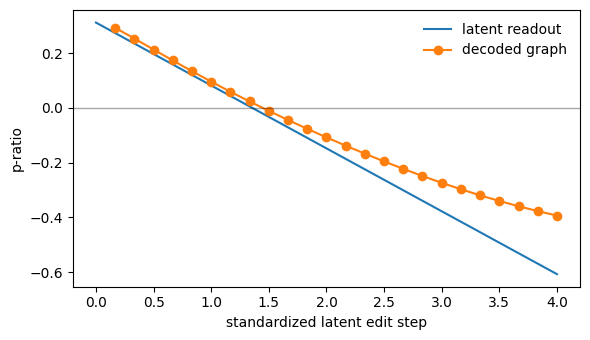

In [5]:
p_ratio_table = outputs["p_ratio_table"]
display(p_ratio_table.head())
display(p_ratio_table.tail())

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(p_ratio_table["edit_step"], p_ratio_table["predicted_p_ratio"], label="latent readout")
ax.plot(p_ratio_table["edit_step"], p_ratio_table["decoded_p_ratio"], "o-", label="decoded graph")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.35)
ax.set_xlabel("standardized latent edit step")
ax.set_ylabel("p-ratio")
ax.legend(frameon=False)
fig.tight_layout()

In [6]:
metaforge_validation = outputs["metaforge_validation"]
if len(metaforge_validation):
    display(metaforge_validation)
else:
    print("MetaForge validation was not run.")

,frame,metaforge_status,rest_lengths,metaforge_p_ratio,bulk_modulus,shear_modulus,run_dir,fast_screening,reused_topology,lj_active,error
0,0,ok,decoded_geometry,0.398065,107.721716,46.379484,/home/alexz/Documents/course_project/notebooks...,True,False,False,
1,24,ok,decoded_geometry,0.397685,107.688489,46.407016,/home/alexz/Documents/course_project/notebooks...,True,False,False,


/home/alexz/Documents/course_project/notebooks/results/06_low_temp_auxetic_latent_edit/decoded_auxetic_edit_sim_080.gif


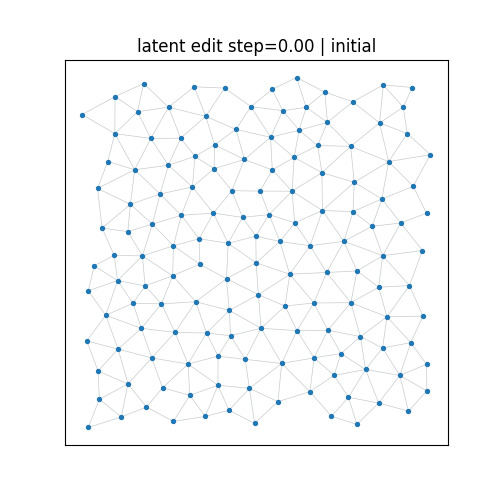

In [7]:
gif_path = outputs["summary"]["gif_path"]
print(gif_path)
display(Image(filename=gif_path))